<a href="https://colab.research.google.com/github/larissafransob/mentoria1/blob/main/Amazon_Sales_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Este notebook contém a análise exploratória das vendas da Amazon durante os anos 2022 e 2023. O dataset, obtido no Kagle e armazenado neste [link](https://docs.google.com/spreadsheets/d/1T-10sEds72c5lhMqj0_PowuI3aTxDZ2otgAs8reMOOA/export?format=csv)  contém 50.000 transações de venda do e-commerce, incluindo informações sobre os pedidos, categorias de produtos, descontos, região do cliente, métodos de pagamento e receita de vendas.

In [1]:
import pandas as pd

url = "https://docs.google.com/spreadsheets/d/1T-10sEds72c5lhMqj0_PowuI3aTxDZ2otgAs8reMOOA/export?format=csv"

df = pd.read_csv(url)

df.head()

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue
0,1,2022-04-13,2637,Books,128.75,10,4,North America,UPI,3.5,443,115.88,463.52
1,2,2023-03-12,2300,Fashion,302.60,20,5,Asia,Credit Card,3.7,475,242.08,1210.40
2,3,2022-09-28,3670,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,793.28
3,4,2022-04-17,2522,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,1264.64
4,5,2022-03-13,1717,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,806.72


In [2]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          50000 non-null  int64  
 1   order_date        50000 non-null  object 
 2   product_id        50000 non-null  int64  
 3   product_category  50000 non-null  object 
 4   price             50000 non-null  float64
 5   discount_percent  50000 non-null  int64  
 6   quantity_sold     50000 non-null  int64  
 7   customer_region   50000 non-null  object 
 8   payment_method    50000 non-null  object 
 9   rating            50000 non-null  float64
 10  review_count      50000 non-null  int64  
 11  discounted_price  50000 non-null  float64
 12  total_revenue     50000 non-null  float64
dtypes: float64(4), int64(5), object(4)
memory usage: 5.0+ MB


In [7]:
df['order_date'] = pd.to_datetime(df['order_date']) # aqui eu converti a coluna order_date em data


In [8]:
# criei colunas de dia, mês e ano para trabalhar com análise temporal
df['year'] = df['order_date'].dt.year
df['month'] = df['order_date'].dt.month
df['day'] = df['order_date'].dt.day

In [9]:
df.info() # confirmei as alterações acima

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          50000 non-null  int64         
 1   order_date        50000 non-null  datetime64[ns]
 2   product_id        50000 non-null  int64         
 3   product_category  50000 non-null  object        
 4   price             50000 non-null  float64       
 5   discount_percent  50000 non-null  int64         
 6   quantity_sold     50000 non-null  int64         
 7   customer_region   50000 non-null  object        
 8   payment_method    50000 non-null  object        
 9   rating            50000 non-null  float64       
 10  review_count      50000 non-null  int64         
 11  discounted_price  50000 non-null  float64       
 12  total_revenue     50000 non-null  float64       
 13  year              50000 non-null  int32         
 14  month             5000

In [10]:
df.describe()

,order_id,order_date,product_id,price,discount_percent,quantity_sold,rating,review_count,discounted_price,total_revenue,year,month,day
count,50000.000000,50000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.0000,50000.000000
mean,25000.500000,2022-12-31 10:47:16.800000256,2986.848740,252.507260,13.340700,2.999400,2.996316,249.329280,218.886566,657.331475,2022.501480,6.5044,15.790820
min,1.000000,2022-01-01 00:00:00,1000.000000,5.010000,0.000000,1.000000,1.000000,0.000000,3.530000,3.840000,2022.000000,1.0000,1.000000
25%,12500.750000,2022-07-02 00:00:00,1983.000000,127.840000,5.000000,2.000000,2.000000,125.000000,109.680000,240.320000,2022.000000,4.0000,8.000000
50%,25000.500000,2023-01-02 00:00:00,2983.000000,252.970000,10.000000,3.000000,3.000000,250.000000,215.805000,505.410000,2023.000000,7.0000,16.000000
75%,37500.250000,2023-07-02 00:00:00,3989.000000,376.335000,20.000000,4.000000,4.000000,374.000000,322.702500,968.970000,2023.000000,9.0000,23.000000
max,50000.000000,2023-12-31 00:00:00,4999.000000,499.990000,30.000000,5.000000,5.000000,499.000000,499.910000,2499.550000,2023.000000,12.0000,31.000000
std,14433.901067,NaN,1156.374535,143.025544,9.850694,1.415401,1.154295,144.251981,127.317681,526.223968,0.500003,3.4360,8.799767


In [11]:
df.describe(include='object')

,product_category,customer_region,payment_method
count,50000,50000,50000
unique,6,4,5
top,Beauty,Asia,Wallet
freq,8465,12526,10106


In [12]:
total_orders = df['order_id'].nunique()
total_revenue = df['total_revenue'].sum()
total_quantity = df['quantity_sold'].sum()
avg_order_value = df.groupby('order_id')['total_revenue'].sum().mean()

print(f"Total Orders: {total_orders:,}")
print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"Total Quantity Sold: {total_quantity:,}")
print(f"Average Order Value: ${avg_order_value:,.2f}")

Total Orders: 50,000
Total Revenue: $32,866,573.74
Total Quantity Sold: 149,970
Average Order Value: $657.33


In [13]:
revenue_by_category = df.groupby('product_category')['total_revenue'].sum().sort_values(ascending=False)

print(revenue_by_category)

product_category
Beauty            5550624.97
Books             5484863.03
Fashion           5480123.34
Home & Kitchen    5473132.55
Electronics       5470594.03
Sports            5407235.82
Name: total_revenue, dtype: float64


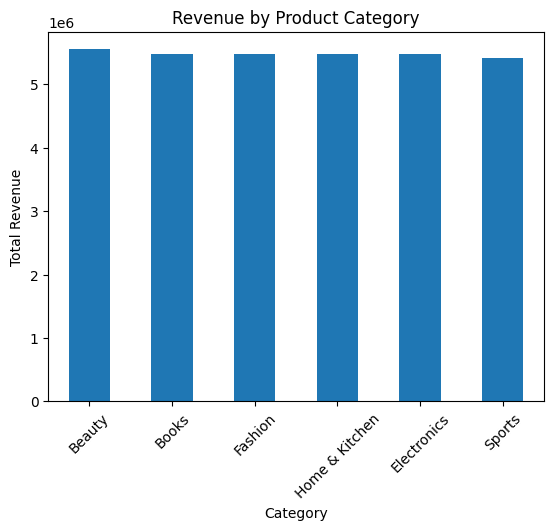

In [14]:
import matplotlib.pyplot as plt

revenue_by_category.plot(kind='bar')

plt.title("Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.show()

In [15]:
revenue_by_customer_region = df.groupby('customer_region')['total_revenue'].sum().sort_values(ascending=False)
print(revenue_by_customer_region)

customer_region
Middle East      8301844.50
North America    8277217.84
Asia             8175199.83
Europe           8112311.57
Name: total_revenue, dtype: float64


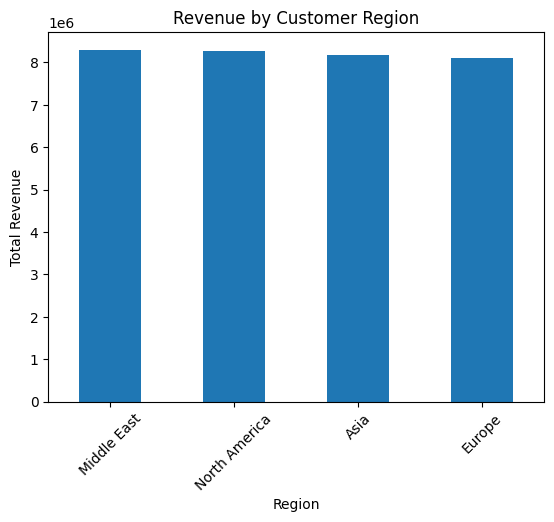

In [16]:
revenue_by_customer_region.plot(kind='bar')

plt.title("Revenue by Customer Region")
plt.xlabel("Region")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.show()

In [17]:
payment_counts = df['payment_method'].value_counts()
print(payment_counts)

payment_method
Wallet              10106
UPI                 10078
Debit Card           9981
Cash on Delivery     9927
Credit Card          9908
Name: count, dtype: int64


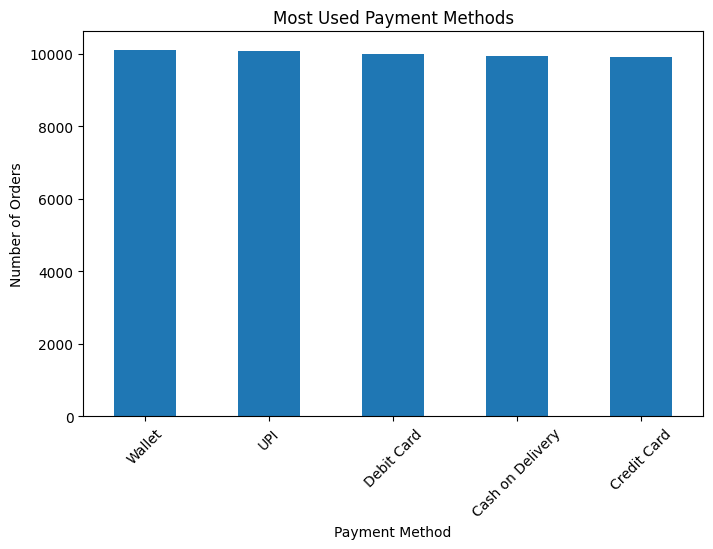

In [18]:
payment_counts.plot(kind='bar', figsize=(8,5))
plt.title('Most Used Payment Methods')
plt.xlabel('Payment Method')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.show()

In [19]:
discount_analysis = (
    df.groupby('discount_percent')[['quantity_sold', 'total_revenue']]
    .mean()
)

print(discount_analysis)

                  quantity_sold  total_revenue
discount_percent                              
0                      2.986490     749.033022
5                      2.995644     727.819529
10                     2.999759     690.568783
15                     3.003369     640.445717
20                     3.028763     614.636293
30                     2.982241     521.556386


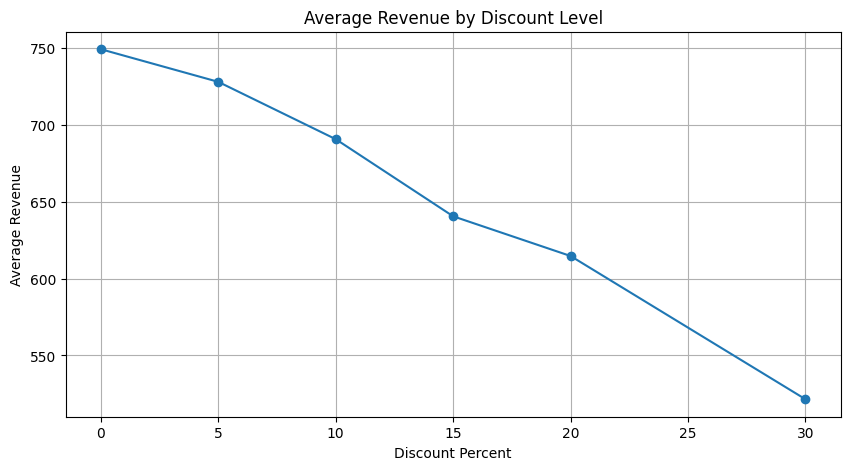

In [20]:
discount_analysis['total_revenue'].plot(figsize=(10,5), marker='o')
plt.title('Average Revenue by Discount Level')
plt.xlabel('Discount Percent')
plt.ylabel('Average Revenue')
plt.grid(True)
plt.show()

In [21]:
monthly_revenue = (
    df.groupby(df['order_date'].dt.to_period('M'))['total_revenue']
    .sum()
)

monthly_revenue.index = monthly_revenue.index.astype(str)

print(monthly_revenue.head())

order_date
2022-01    1419751.89
2022-02    1266714.29
2022-03    1392585.42
2022-04    1371955.83
2022-05    1374779.57
Name: total_revenue, dtype: float64


In [22]:
monthly_revenue = (
    df.groupby(['year', 'month'])['total_revenue']
    .sum()
    .reset_index()
)

In [23]:
revenue_pivot = monthly_revenue.pivot(
    index='month',
    columns='year',
    values='total_revenue'
)

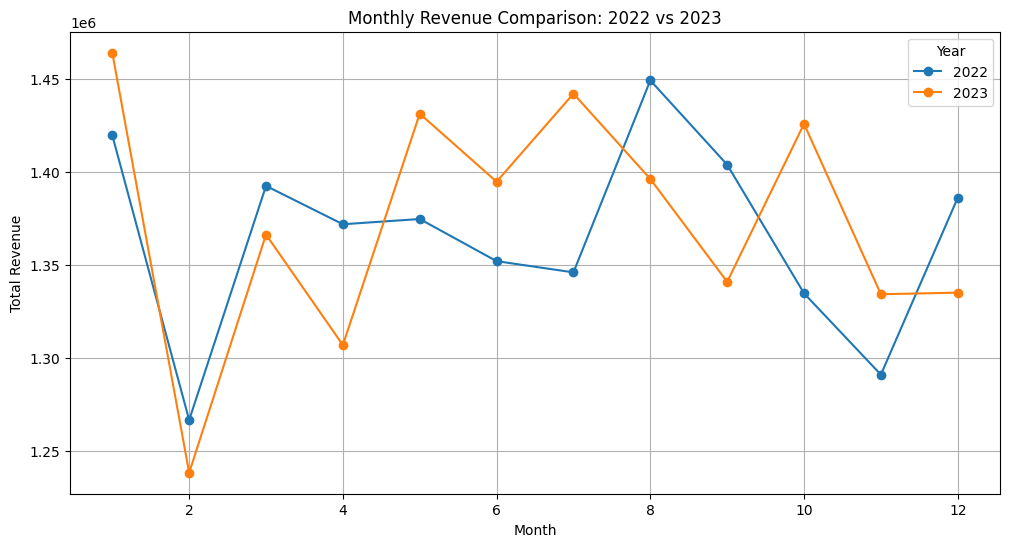

In [24]:
import matplotlib.pyplot as plt

revenue_pivot.plot(figsize=(12,6), marker='o')

plt.title("Monthly Revenue Comparison: 2022 vs 2023")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.grid(True)
plt.legend(title="Year")

plt.show()

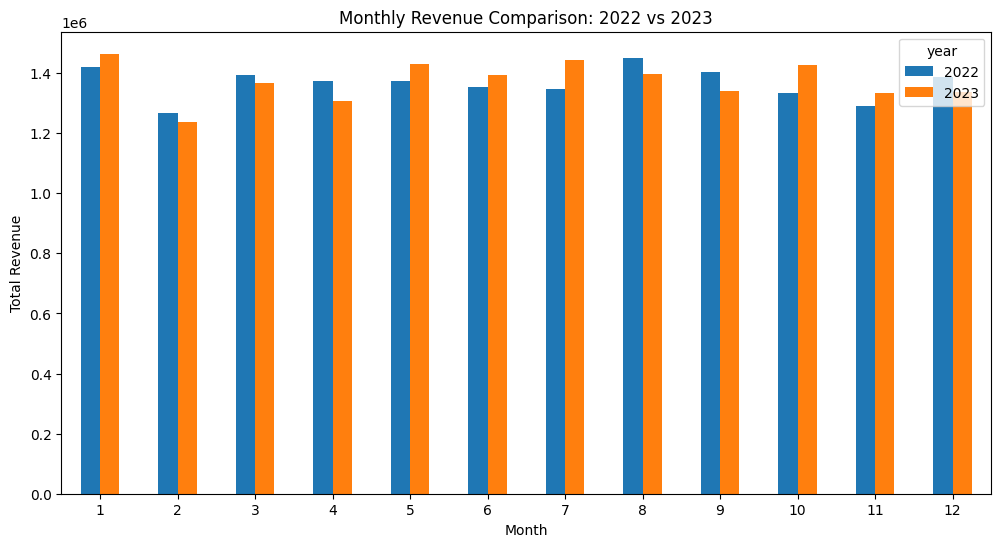

In [25]:
revenue_pivot.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title("Monthly Revenue Comparison: 2022 vs 2023")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.xticks(rotation=0)

plt.show()

In [26]:
top_products = (
    df.groupby('product_id')['total_revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_products)

product_id
1931    18885.83
1087    18531.52
1328    18306.73
3537    18071.02
2837    17855.07
1266    17819.13
4386    17806.08
4264    17803.51
3700    17619.14
3377    17201.38
Name: total_revenue, dtype: float64


In [27]:
bottom_products = (
    df.groupby('product_id')['total_revenue']
    .sum()
    .sort_values(ascending=True)
    .head(10)
)

print(bottom_products)

product_id
3694     558.54
3054    1050.78
4514    1063.20
4028    1088.07
3715    1162.27
1425    1297.63
2297    1314.51
4893    1379.32
4702    1425.52
3826    1621.38
Name: total_revenue, dtype: float64


In [28]:
df.groupby('product_id')['rating'].nunique().sort_values(ascending=False)

,rating
product_id,
1580,21
4256,21
2923,21
4778,20
3984,20
...,...
4830,3
3054,3
4536,3


Um mesmo ID de produto está classificado com categorias diferentes. Isso é uma falha de quem criou este dataset.

In [29]:
df[df['product_id'] == 1580]

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue,year,month,day
2708,2709,2022-08-09,1580,Fashion,247.24,20,4,Asia,Cash on Delivery,4.7,399,197.79,791.16,2022,8,9
3882,3883,2022-12-27,1580,Electronics,264.98,10,5,Asia,Debit Card,3.7,254,238.48,1192.40,2022,12,27
3945,3946,2023-09-11,1580,Fashion,43.28,0,4,Middle East,Wallet,4.8,275,43.28,173.12,2023,9,11
6009,6010,2023-05-11,1580,Books,22.08,5,3,Europe,Debit Card,4.6,431,20.98,62.94,2023,5,11
6708,6709,2022-01-18,1580,Sports,27.19,30,5,Europe,UPI,2.5,338,19.03,95.15,2022,1,18
9977,9978,2023-06-06,1580,Electronics,393.58,5,4,Europe,Debit Card,1.8,440,373.90,1495.60,2023,6,6
11881,11882,2023-07-08,1580,Sports,99.45,20,4,Middle East,UPI,4.9,239,79.56,318.24,2023,7,8
12008,12009,2023-05-12,1580,Home & Kitchen,207.88,10,5,Middle East,UPI,1.4,467,187.09,935.45,2023,5,12
16992,16993,2022-11-26,1580,Sports,15.50,5,1,North America,Wallet,1.3,105,14.72,14.72,2022,11,26
19718,19719,2022-06-22,1580,Electronics,248.19,30,4,North America,Debit Card,2.2,126,173.73,694.92,2022,6,22


Após analisar os dados das vendas, dividi o dataset em dois conjuntos de dados. Dados do produto e dados da venda.

In [58]:
product_data = (
    df.groupby('product_id', as_index=False)
      .agg({
          'product_category': 'first',
          'price': 'first',
          'review_count': 'max'
      })
)

product_data['product_id'].duplicated().sum()

np.int64(0)

In [30]:
#product_data = df[[
#    'product_id',
#    'product_category',
#    'price',
#    'review_count'
#]].drop_duplicates()

In [60]:
sales_data = df[[
    'order_id',
    'order_date',
    'product_id',
    'quantity_sold',
    'customer_region',
    'payment_method',
    'discount_percent',
    'rating',
    'discounted_price',
    'total_revenue'
]]

In [61]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [62]:
import os
import sqlite3
import pandas as pd

db_path = '/content/drive/MyDrive/ecommerce.db'

# apagar arquivo antigo, se existir
if os.path.exists(db_path):
    os.remove(db_path)

# criar conexão
conn = sqlite3.connect(db_path)

# gravar tabelas
product_data.to_sql('products', conn, if_exists='append', index=False)
sales_data.to_sql('sales', conn, if_exists='append', index=False)

# confirmar gravação
conn.commit()

# fechar conexão
conn.close()

In [65]:
import os
os.path.getsize('/content/drive/MyDrive/ecommerce.db')

4321280

In [66]:
conn = sqlite3.connect('/content/drive/MyDrive/ecommerce.db')

print(pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", conn))
print(pd.read_sql("SELECT * FROM products LIMIT 5;", conn))
print(pd.read_sql("SELECT * FROM sales LIMIT 5;", conn))

conn.close()

       name
0  products
1     sales
   product_id product_category   price  review_count
0        1000      Electronics  484.94           475
1        1001   Home & Kitchen  228.16           477
2        1002      Electronics  443.87           499
3        1003            Books  246.78           499
4        1004           Sports   42.93           482
   order_id           order_date  product_id  quantity_sold customer_region  \
0         1  2022-04-13 00:00:00        2637              4   North America   
1         2  2023-03-12 00:00:00        2300              5            Asia   
2         3  2022-09-28 00:00:00        3670              2          Europe   
3         4  2022-04-17 00:00:00        2522              4     Middle East   
4         5  2022-03-13 00:00:00        1717              4     Middle East   

  payment_method  discount_percent  rating  discounted_price  total_revenue  
0            UPI                10     3.5            115.88         463.52  
1    Credit Car

In [67]:
from google.colab import files
files.download('/content/drive/MyDrive/ecommerce.db')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Agora em Spark

In [37]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("EcommerceAnalysis") \
    .getOrCreate()

In [38]:
#converter pandas em spark
spark_products = spark.createDataFrame(product_data)
spark_sales = spark.createDataFrame(sales_data)

In [39]:
spark.sql("CREATE DATABASE IF NOT EXISTS ecommerce")

DataFrame[]

In [40]:
#salvar tabela de produtos
spark_products.write \
    .mode("overwrite") \
    .saveAsTable("ecommerce.products")

In [41]:
#salvar tabela de vendas
spark_sales.write \
    .mode("overwrite") \
    .saveAsTable("ecommerce.sales")

In [42]:
#ver as tabelas
spark.sql("SHOW TABLES IN ecommerce").show()

+---------+---------+-----------+
|namespace|tableName|isTemporary|
+---------+---------+-----------+
|ecommerce| products|      false|
|ecommerce|    sales|      false|
+---------+---------+-----------+



In [43]:
spark.sql("SELECT * FROM ecommerce.products").show()

+----------+----------------+------+------------+
|product_id|product_category| price|review_count|
+----------+----------------+------+------------+
|      3087|         Fashion|459.75|         349|
|      1475|          Sports|244.75|         386|
|      2137|          Beauty|229.42|         125|
|      4397|          Beauty|281.47|         391|
|      1678|          Beauty| 86.51|         494|
|      1837|         Fashion|402.49|         315|
|      4693|  Home & Kitchen| 21.45|          20|
|      1531|           Books| 32.86|         247|
|      1229|          Beauty|  32.8|         152|
|      4459|          Sports|397.34|         394|
|      4032|           Books| 187.3|         175|
|      3828|           Books|323.41|         368|
|      4376|          Beauty| 44.37|         166|
|      3123|         Fashion|382.53|         278|
|      3312|     Electronics|170.72|         350|
|      3362|     Electronics|111.69|         472|
|      3675|     Electronics|358.81|         434|


In [44]:
spark.sql("SELECT * FROM ecommerce.sales").show()

+--------+-------------------+----------+-------------+---------------+----------------+----------------+------+----------------+-------------+
|order_id|         order_date|product_id|quantity_sold|customer_region|  payment_method|discount_percent|rating|discounted_price|total_revenue|
+--------+-------------------+----------+-------------+---------------+----------------+----------------+------+----------------+-------------+
|   24577|2022-11-04 00:00:00|      3087|            4|    Middle East|      Debit Card|              20|   2.5|           367.8|       1471.2|
|   24578|2023-11-02 00:00:00|      1475|            3|  North America|     Credit Card|              15|   4.8|          208.04|       624.12|
|   24579|2022-12-06 00:00:00|      2137|            4|           Asia|          Wallet|               0|   2.6|          229.42|       917.68|
|   24580|2022-12-18 00:00:00|      4397|            3|    Middle East|          Wallet|              30|   1.2|          197.03|       

In [45]:
spark.conf.get("spark.sql.warehouse.dir")

'file:/content/spark-warehouse'

In [46]:
!ls /content/spark-warehouse

ecommerce.db


In [47]:
!ls /content/spark-warehouse/ecommerce.db

products  sales


In [48]:
#exportar tabela produto
spark.table("ecommerce.products") \
     .write \
     .mode("overwrite") \
     .parquet("products_parquet")

In [49]:
#exportar tabela vendas
spark.table("ecommerce.sales") \
     .write \
     .mode("overwrite") \
     .parquet("sales_parquet")

In [50]:
#exportar as duas tabelas como .csv
spark.table("ecommerce.products") \
     .write \
     .mode("overwrite") \
     .option("header", True) \
     .csv("products_csv")

spark.table("ecommerce.sales") \
     .write \
     .mode("overwrite") \
     .option("header", True) \
     .csv("sales_csv")

In [51]:
!zip -r products.zip products_csv
!zip -r sales.zip sales_csv

  adding: products_csv/ (stored 0%)
  adding: products_csv/._SUCCESS.crc (stored 0%)
  adding: products_csv/.part-00000-71fde703-f3bc-4e82-b7c3-20c10ac3f291-c000.csv.crc (stored 0%)
  adding: products_csv/part-00001-71fde703-f3bc-4e82-b7c3-20c10ac3f291-c000.csv (deflated 66%)
  adding: products_csv/part-00000-71fde703-f3bc-4e82-b7c3-20c10ac3f291-c000.csv (deflated 66%)
  adding: products_csv/_SUCCESS (stored 0%)
  adding: products_csv/.part-00001-71fde703-f3bc-4e82-b7c3-20c10ac3f291-c000.csv.crc (stored 0%)
  adding: sales_csv/ (stored 0%)
  adding: sales_csv/part-00001-f796e9b0-805e-46a1-b0fc-6f141048074a-c000.csv (deflated 75%)
  adding: sales_csv/._SUCCESS.crc (stored 0%)
  adding: sales_csv/part-00000-f796e9b0-805e-46a1-b0fc-6f141048074a-c000.csv (deflated 75%)
  adding: sales_csv/.part-00001-f796e9b0-805e-46a1-b0fc-6f141048074a-c000.csv.crc (stored 0%)
  adding: sales_csv/.part-00000-f796e9b0-805e-46a1-b0fc-6f141048074a-c000.csv.crc (stored 0%)
  adding: sales_csv/_SUCCESS (stored

In [52]:
from google.colab import files
files.download("products.zip")
files.download("sales.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [53]:
#exportar direto para jason
spark.table("ecommerce.sales") \
     .write \
     .mode("overwrite") \
     .json("sales_json")

Após exportar o banco de dados ecommerce.db para o SQL e estruturá-lo por lá (criei primary e foreign key) e depois salvei como db_estruturado.db e a partir de agora é com ele que vamos trabalhar aqui. Eu coloquei o banco de dados neste link https://drive.google.com/file/d/16ooUmebKsWPsIY5FOBl_qTF913rtmQS7/view?usp=sharing

In [68]:
!pip install gdown

import gdown

file_id = "16ooUmebKsWPsIY5FOBl_qTF913rtmQS7"
url = f"https://drive.google.com/uc?id={file_id}"

gdown.download(url, "db_estruturado.db", quiet=False)

Downloading...
From: https://drive.google.com/uc?id=16ooUmebKsWPsIY5FOBl_qTF913rtmQS7
To: /content/db_estruturado.db
100%|██████████| 8.51M/8.51M [00:00<00:00, 23.0MB/s]


'db_estruturado.db'

In [69]:
import sqlite3

conn = sqlite3.connect("db_estruturado.db")
cursor = conn.cursor()

cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
print(cursor.fetchall())

[('products',), ('sales',)]


In [78]:
pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", conn)

,name
0,products
1,sales


In [76]:
import pandas as pd

products = pd.read_sql_query("SELECT * FROM products", conn)
sales = pd.read_sql_query("SELECT * FROM sales", conn)

products.head()


,product_id,product_category,price,review_count
0,1000,Electronics,484.94,475
1,1001,Home & Kitchen,228.16,477
2,1002,Electronics,443.87,499
3,1003,Books,246.78,499
4,1004,Sports,42.93,482


In [77]:
sales.head()

,order_id,order_date,product_id,quantity_sold,customer_region,payment_method,discount_percent,rating,discounted_price,total_revenue
0,1,2022-04-13 00:00:00,2637,4,North America,UPI,10,3.5,115.88,463.52
1,2,2023-03-12 00:00:00,2300,5,Asia,Credit Card,20,3.7,242.08,1210.40
2,3,2022-09-28 00:00:00,3670,2,Europe,UPI,20,4.4,396.64,793.28
3,4,2022-04-17 00:00:00,2522,4,Middle East,UPI,15,5.0,316.16,1264.64
4,5,2022-03-13 00:00:00,1717,4,Middle East,UPI,0,4.6,201.68,806.72


In [79]:
query = """
SELECT
    s.order_id,
    s.order_date,
    s.product_id,
    p.product_category,
    p.price,
    p.review_count,
    s.quantity_sold,
    s.customer_region,
    s.payment_method,
    s.discount_percent,
    s.rating,
    s.discounted_price,
    s.total_revenue
FROM sales s
JOIN products p
ON s.product_id = p.product_id
ORDER BY s.order_id
"""

joined_df = pd.read_sql(query, conn)

joined_df.head()

,order_id,order_date,product_id,product_category,price,review_count,quantity_sold,customer_region,payment_method,discount_percent,rating,discounted_price,total_revenue
0,1,2022-04-13 00:00:00,2637,Books,128.75,443,4,North America,UPI,10,3.5,115.88,463.52
1,2,2023-03-12 00:00:00,2300,Fashion,302.60,497,5,Asia,Credit Card,20,3.7,242.08,1210.40
2,3,2022-09-28 00:00:00,3670,Sports,495.80,447,2,Europe,UPI,20,4.4,396.64,793.28
3,4,2022-04-17 00:00:00,2522,Books,371.95,494,4,Middle East,UPI,15,5.0,316.16,1264.64
4,5,2022-03-13 00:00:00,1717,Beauty,201.68,481,4,Middle East,UPI,0,4.6,201.68,806.72


In [80]:
joined_df.to_csv("dados_unificados.csv", index=False)

In [81]:
from google.colab import files
files.download("dados_unificados.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [83]:
#transforma cada linha da tabela em um documento estruturado
mongo_docs = []

for _, row in joined_df.iterrows():
    doc = {
        "order_id": int(row["order_id"]),
        "order_date": str(row["order_date"]),
        "product": {
            "product_id": int(row["product_id"]),
            "category": row["product_category"],
            "price": float(row["price"]),
            "review_count": int(row["review_count"])
        },
        "sale": {
            "quantity_sold": int(row["quantity_sold"]),
            "discount_percent": int(row["discount_percent"]),
            "discounted_price": float(row["discounted_price"]),
            "total_revenue": float(row["total_revenue"])
        },
        "customer": {
            "region": row["customer_region"]
        },
        "payment": {
            "method": row["payment_method"]
        },
        "feedback": {
            "rating": float(row["rating"])
        }
    }

    mongo_docs.append(doc)

In [84]:
mongo_docs[:2]

[{'order_id': 1,
  'order_date': '2022-04-13 00:00:00',
  'product': {'product_id': 2637,
   'category': 'Books',
   'price': 128.75,
   'review_count': 443},
  'sale': {'quantity_sold': 4,
   'discount_percent': 10,
   'discounted_price': 115.88,
   'total_revenue': 463.52},
  'customer': {'region': 'North America'},
  'payment': {'method': 'UPI'},
  'feedback': {'rating': 3.5}},
 {'order_id': 2,
  'order_date': '2023-03-12 00:00:00',
  'product': {'product_id': 2300,
   'category': 'Fashion',
   'price': 302.6,
   'review_count': 497},
  'sale': {'quantity_sold': 5,
   'discount_percent': 20,
   'discounted_price': 242.08,
   'total_revenue': 1210.4},
  'customer': {'region': 'Asia'},
  'payment': {'method': 'Credit Card'},
  'feedback': {'rating': 3.7}}]

In [85]:
#criar o arquivo jason

import json

with open("ecommerce_structured.json", "w", encoding="utf-8") as f:
    json.dump(mongo_docs, f, ensure_ascii=False, indent=4)

In [86]:
#baixar o arquivo json
from google.colab import files
files.download("ecommerce_structured.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>